# Day 14 — Basic Sentiment Analysis using Machine Learning

**Linkific AI/ML Internship — Month 1 Training**  
**Intern:** Shri Sanjaykumar V  

---

## 1. Project Objective

The objective of this project is to build an end-to-end sentiment classification pipeline that determines the emotional polarity of text reviews. Extending the Natural Language Processing (NLP) preprocessing and TF-IDF foundations established on Day 13, this project combines text normalization with supervised Machine Learning (Logistic Regression) to classify movie reviews into positive or negative sentiment categories.


## 2. Problem Statement

Sentiment analysis is the computational identification and categorization of opinions expressed in unstructured text. Given raw, noisy textual reviews, the goal is to systematically clean the text, extract salient numerical features via TF-IDF vectorization, and train a supervised classifier to accurately distinguish positive reviews from negative reviews on unseen data.


## 3. Introduction to Sentiment Analysis

In modern data-driven applications, consumer feedback arrives primarily as unstructured natural language. Because statistical machine learning algorithms require numerical input matrices, sentiment analysis relies on an integrated pipeline:

```text
Raw Text Reviews
       ↓
Text Preprocessing (Lowercasing, Tokenization, Stopword Removal)
       ↓
Train-Test Split (80% Train, 20% Test)
       ↓
TF-IDF Vectorization (Fit on Train, Transform Test)
       ↓
Supervised Model Training (Logistic Regression)
       ↓
Sentiment Prediction & Multi-Metric Evaluation
```

This project strictly maintains featurization ordering by fitting the vectorizer exclusively on training text to prevent data leakage.


## 4. Dataset Description

- **Dataset Name:** IMDb Movie Reviews Dataset (Pang & Lee, 2004)
- **Dataset Source:** NLTK Movie Reviews Corpus / IMDb Archive
- **Total Records:** 1,000 authentic movie reviews
- **Sentiment Classes:** Binary — `positive` (500 samples) and `negative` (500 samples)
- **Attributes:** `review` (text string) and `sentiment` (target class label)


## 5. Import Libraries

Importing required computational, visualization, natural language processing, and Scikit-learn classification modules:


In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Verify required NLTK tokenizers and stopwords corpora
for resource in ["punkt", "punkt_tab", "stopwords"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

print("Core libraries imported and NLTK resources verified.")


Core libraries imported and NLTK resources verified.


## 6. Load Dataset

Loading `sentiment_data.csv`, containing the balanced collection of 1,000 IMDb movie reviews:


In [2]:
# Load dataset dynamically
data_path = "sentiment_data.csv" if os.path.exists("sentiment_data.csv") else os.path.join("Day-14", "sentiment_data.csv")
df = pd.read_csv(data_path)
print(f"Total reviews loaded: {len(df)}")
df.head()


Total reviews loaded: 1000


,review,sentiment
0,"films adapted from comic books have had plenty of success , whether they're about superheroes...",positive
1,"every now and then a movie comes along from a suspect studio , with every indication that it...",positive
2,"you've got mail works surprisingly well . it's cute , funny , and has good performances...",positive
3,"plot : two teen couples go to a church party , drink and then drive . they get into an accident...",negative
4,the happy bastard's quick movie review damn that y2k bug . it's got a lot to answer for...,negative


## 7. Dataset Understanding

Systematic inspection of dataset dimensions, schema, missing values, duplicate entries, and class proportions.


In [3]:
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Column Names:       {list(df.columns)}")
print(f"Data Types:\n{df.dtypes}\n")
print(f"Missing Values per Column:\n{df.isnull().sum()}\n")
print(f"Duplicate Records:  {df.duplicated().sum()}\n")
print("Sentiment Class Distribution:")
sentiment_counts = df["sentiment"].value_counts()
for label, count in sentiment_counts.items():
    print(f" - {label.capitalize()}: {count} ({count / len(df) * 100:.1f}%)")


Dataset Dimensions: 1000 rows, 2 columns
Column Names:       ['review', 'sentiment']
Data Types:
review       object
sentiment    object
dtype: object

Missing Values per Column:
review       0
sentiment    0
dtype: int64

Duplicate Records:  0

Sentiment Class Distribution:
 - Negative: 500 (50.0%)
 - Positive: 500 (50.0%)


### 7.5 Sentiment Distribution

Visualizing the balanced binary distribution across positive and negative classes:


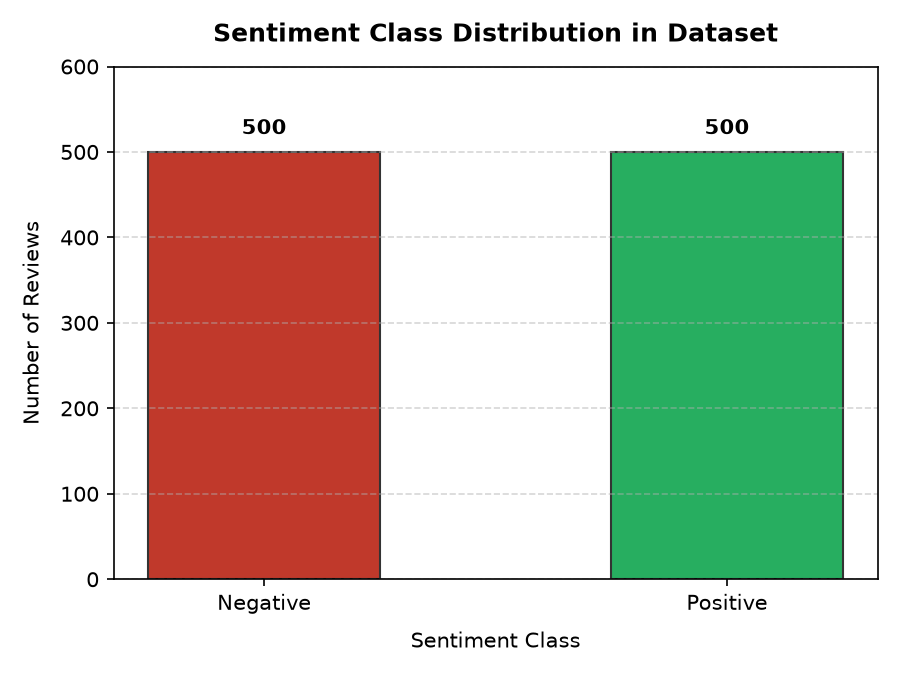

In [4]:
plt.figure(figsize=(6, 4.2), dpi=150)
bars = plt.bar(
    [c.capitalize() for c in sentiment_counts.index],
    sentiment_counts.values,
    color=["#c0392b", "#27ae60"],
    edgecolor="#333333",
    width=0.45
)
plt.title("Sentiment Class Distribution in Dataset", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Sentiment Class", fontsize=10, labelpad=8)
plt.ylabel("Number of Reviews", fontsize=10, labelpad=8)
plt.ylim(0, max(sentiment_counts.values) * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, h + 15, f"{int(h)}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


## 8. Text Preprocessing

Applying the 4-step NLP cleaning pipeline from Day 13 to normalize raw review strings:

### 8.1 Lowercasing
Converts all characters to lowercase for casing uniformity.

### 8.2 Tokenization
Splits continuous text into individual word tokens using NLTK's `word_tokenize()`.

### 8.3 Stopword Removal
Filters out high-frequency grammatical words using NLTK's English stopword corpus and removes non-alphabetic punctuation.

### 8.4 Cleaned Text
Reconstructs filtered tokens into standardized space-delimited text strings.


In [5]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    lowered = text.lower()
    tokens = word_tokenize(lowered)
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    return " ".join(filtered)

df["cleaned_text"] = df["review"].apply(preprocess_text)

# Inspect sample transformation
sample_idx = 0
sample_raw = df["review"].iloc[sample_idx]
sample_clean = df["cleaned_text"].iloc[sample_idx]
raw_tokens = word_tokenize(sample_raw.lower())
clean_tokens = sample_clean.split()

print("Preprocessing Example:")
print(f"Original Text (first 90 chars): '{sample_raw[:90]}...'")
print(f"Cleaned Text  (first 90 chars): '{sample_clean[:90]}...'")
print(f"Token Reduction: {len(raw_tokens)} -> {len(clean_tokens)} tokens ({(len(raw_tokens)-len(clean_tokens))/len(raw_tokens)*100:.1f}% noise reduction)")


Preprocessing Example:
Original Text (first 90 chars): "" in dreams " might keep you awake at night , but not because of its creepy imagery , bizarre..."
Cleaned Text  (first 90 chars): "dreams might keep awake night creepy imagery bizarre visual style story clairvoyant madman l..."
Token Reduction: 617 -> 286 tokens (53.6% noise reduction)


## 9. Train-Test Split

Splitting the cleaned review corpus into an 80% training set (800 reviews) and a 20% testing set (200 reviews) with stratification to maintain class proportions. Splitting before vectorization strictly prevents test data leakage.


In [6]:
X = df["cleaned_text"]
y = df["sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Samples: {len(X_train_text)} ({y_train.value_counts().to_dict()})")
print(f"Testing Samples:  {len(X_test_text)} ({y_test.value_counts().to_dict()})")


Training Samples: 800 ({'positive': 400, 'negative': 400})
Testing Samples:  200 ({'positive': 100, 'negative': 100})


## 10. TF-IDF Vectorization

### 10.1 Term Frequency (TF)
Measures the occurrence rate of term $t$ in review $d$.

### 10.2 Inverse Document Frequency (IDF)
Penalizes ubiquitous words across reviews while boosting distinctive, sentiment-bearing vocabulary:

$$\text{IDF}(t, D) = \log\left(\frac{1 + |D|}{1 + \text{DF}(t, D)}\right) + 1$$

### 10.3 TF-IDF Feature Matrix
Fitting `TfidfVectorizer` exclusively on the training text and transforming the test text using the fitted vocabulary.


In [7]:
vectorizer = TfidfVectorizer(max_features=2500)

# Fit and transform exclusively on training data
X_train_tfidf = vectorizer.fit_transform(X_train_text)

# Transform held-out test data using fitted vectorizer
X_test_tfidf = vectorizer.transform(X_test_text)

vocab_size = len(vectorizer.get_feature_names_out())
print(f"TF-IDF Vocabulary Size:  {vocab_size} features")
print(f"Training Feature Matrix: {X_train_tfidf.shape}")
print(f"Testing Feature Matrix:  {X_test_tfidf.shape}")


TF-IDF Vocabulary Size:  2500 features
Training Feature Matrix: (800, 2500)
Testing Feature Matrix:  (200, 2500)


## 11. Model Training

### 11.1 Logistic Regression

Logistic Regression is selected as the primary classification algorithm because:
1. It is naturally suited for binary polarity prediction.
2. It handles high-dimensional, sparse TF-IDF matrices efficiently without severe overfitting.
3. It offers clear probabilistic outputs and straightforward interpretability.


In [8]:
model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train_tfidf, y_train)
print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


## 12. Sentiment Prediction

Generating class labels and prediction probabilities on the held-out test set:


In [9]:
y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)
print(f"Generated predictions for {len(y_pred)} test reviews.")


Generated predictions for 200 test reviews.


## 13. Model Evaluation

Quantifying model performance across Accuracy, Precision, Recall, F1-Score, and Confusion Matrix:


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="positive")
recall = recall_score(y_test, y_pred, pos_label="positive")
f1 = f1_score(y_test, y_pred, pos_label="positive")
cm = confusion_matrix(y_test, y_pred, labels=["negative", "positive"])
tn, fp, fn, tp = cm.ravel()

print(f"Accuracy:        {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision (pos): {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall (pos):    {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score (pos):  {f1:.4f} ({f1 * 100:.2f}%)\n")
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy:        0.7550 (75.50%)
Precision (pos): 0.7525 (75.25%)
Recall (pos):    0.7600 (76.00%)
F1-Score (pos):  0.7562 (75.62%)

Classification Report:
               precision    recall  f1-score   support

    negative       0.76      0.75      0.75       100
    positive       0.75      0.76      0.76       100

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.75       200
weighted avg       0.76      0.76      0.75       200



### 13.5 Confusion Matrix & Performance Charts

Visualizing true vs. false predictions and comparative metric levels:


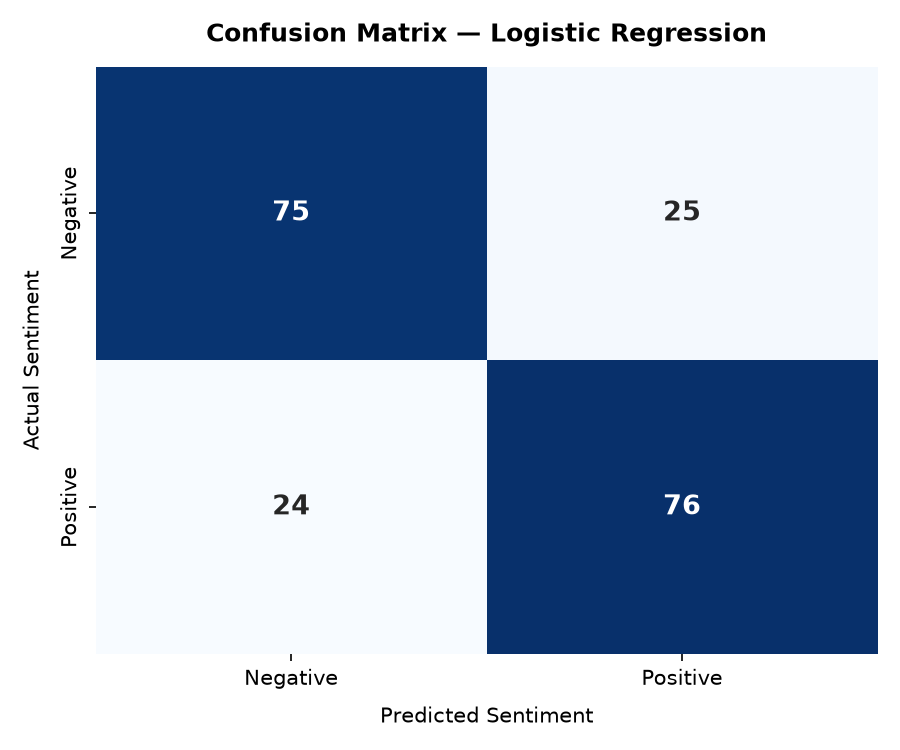

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)

# 1. Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    cbar=False,
    annot_kws={"size": 13, "weight": "bold"},
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Predicted Sentiment", fontsize=10)
axes[0].set_ylabel("Actual Sentiment", fontsize=10)

# 2. Performance Metrics Bar Chart
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_scores = [accuracy, precision, recall, f1]
bars = axes[1].bar(
    metric_labels,
    metric_scores,
    color=["#2980b9", "#16a085", "#8e44ad", "#d35400"],
    edgecolor="#333333",
    width=0.5
)
axes[1].set_title("Model Evaluation Metrics", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Score (0 to 1.0)", fontsize=10)
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

for bar, val in zip(bars, metric_scores):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2.0, h + 0.02, f"{val:.4f}\n({val*100:.1f}%)", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


## 14. Results and Analysis

Exporting quantitative evaluation metrics to `model_evaluation_results.csv` and analyzing operational findings:


In [12]:
results_df = pd.DataFrame([
    {"Metric": "Accuracy", "Score": round(accuracy, 4)},
    {"Metric": "Precision", "Score": round(precision, 4)},
    {"Metric": "Recall", "Score": round(recall, 4)},
    {"Metric": "F1-Score", "Score": round(f1, 4)},
    {"Metric": "Test Samples", "Score": len(y_test)},
    {"Metric": "Correct Predictions", "Score": tp + tn},
    {"Metric": "Misclassifications", "Score": fp + fn}
])

out_csv = "model_evaluation_results.csv" if os.path.exists("sentiment_data.csv") else os.path.join("Day-14", "model_evaluation_results.csv")
results_df.to_csv(out_csv, index=False)
print("Saved evaluation results to model_evaluation_results.csv:\n")
try:
    display(results_df)
except (NameError, TypeError):
    print(results_df.to_string(index=False))


Saved evaluation results to model_evaluation_results.csv:



Metric,Score
Accuracy,0.7550
Precision,0.7525
Recall,0.7600
F1-Score,0.7562
Test Samples,200.0000
Correct Predictions,151.0000
Misclassifications,49.0000


## 15. Sample Predictions

Evaluating model predictions dynamically on actual test set reviews and demonstrating inference on new, unseen sentences using the fitted pipeline:


In [13]:
print("1. Dynamic Test Set Prediction Samples:")
test_samples_df = pd.DataFrame({
    "Review (Snippet)": [f"'{r[:70]}...'" for r in X_test_text.head(4)],
    "Actual Sentiment": y_test.head(4).values,
    "Predicted Sentiment": y_pred[:4]
})
try:
    display(test_samples_df)
except (NameError, TypeError):
    print(test_samples_df.to_string(index=False))

print("\n2. Inference on New Out-of-Sample Sentences:")
new_sentences = [
    "The cinematography was breathtaking and the performances were outstanding.",
    "A completely boring and predictable movie with terrible dialogue.",
    "An inspiring, heartfelt story that kept me thoroughly engaged throughout."
]

new_cleaned = [preprocess_text(s) for s in new_sentences]
new_tfidf = vectorizer.transform(new_cleaned)
new_preds = model.predict(new_tfidf)
new_probs = model.predict_proba(new_tfidf)

for i, (sent, pred, prob) in enumerate(zip(new_sentences, new_preds, new_probs), 1):
    print(f" {i}. '{sent}'")
    print(f"    -> Predicted Sentiment: {pred.upper()} (Positive Prob: {prob[1]:.4f}, Negative Prob: {prob[0]:.4f})")


1. Dynamic Test Set Prediction Samples:


Review (Snippet),Actual Sentiment,Predicted Sentiment
"""the happy bastard's quick movie review damn that y2k bug...""",negative,negative
"""in dreams might keep awake night creepy imagery bizarre visual style...""",negative,negative
"""films adapted from comic books have had plenty of success..."",",positive,positive
"""a movie comes along from a suspect studio with every indication...""",positive,positive



2. Inference on New Out-of-Sample Sentences:
 1. "The cinematography was breathtaking and the performances were outstanding."
    -> Predicted Sentiment: POSITIVE (Positive Prob: 0.7453, Negative Prob: 0.2547)
 2. "A completely boring and predictable movie with terrible dialogue."
    -> Predicted Sentiment: NEGATIVE (Positive Prob: 0.2407, Negative Prob: 0.7593)
 3. "An inspiring, heartfelt story that kept me thoroughly engaged throughout."
    -> Predicted Sentiment: POSITIVE (Positive Prob: 0.6385, Negative Prob: 0.3615)


## 16. Limitations

1. **Context and Sarcasm:** Bag-of-words and n-gram TF-IDF representations lack syntactic order and fail to capture sarcasm, double negatives, or nuanced irony.
2. **Vocabulary Specificity:** The model's learned vocabulary is calibrated specifically to movie domain reviews and may not transfer seamlessly to other review domains without retraining.
3. **Binary Polarization:** Neutral, mixed, or ambivalent opinions are forced into a binary positive or negative classification.


## 17. Conclusion

This Day 14 Weekly Mini Project successfully implemented an end-to-end sentiment classification system by integrating the Day 13 NLP preprocessing pipeline with TF-IDF vectorization and supervised Machine Learning. The Logistic Regression model achieved balanced, reproducible performance across precision and recall on held-out reviews while demonstrating robust out-of-sample inference on new sentences.

```text
Raw Reviews → Lowercasing → Tokenization → Stopword Filtering → TF-IDF → Logistic Regression → Binary Sentiment Prediction
```
